# Recipe Rating Prediction – Exploratory Data Analysis (EDA)

Objective:
Understand user behavior, engagement patterns, and review characteristics to identify factors influencing recipe ratings.

Dataset:
Recipe Ratings Dataset (train.csv)

Problem Type:
Multi-class Classification (Predict rating from 1 to 5)

# Feature Description
- RecipeNumber: Placement of the recipe on the top 100 recipes list
- RecipeCode: Unique ID of the recipe used by the site
- RecipeName: Name of the recipe the comment was posted on
- CommentID: Unique ID of the comment
- UserID: Unique ID of the user who left the comment
- UserName: Name of the user
- UserReputation: Internal score of the site, roughly quantifying the past behavior of the user
- CreationTimestamp: Time at which the comment was posted as a Unix timestamp
- ReplyCount: Number of replies to the comment
- ThumbsUpCount: Number of up-votes the comment has received
- ThumbsDownCount: Number of down-votes the comment has received
- Rating: The score on a 1 to 5 scale that the user gave to the recipe. A score of 0 means that no score was given (Target Variable)
- BestScore: Score of the comment, likely used by the site to help determine the order comments appear in
- Recipe_Review: Text content of the comment


In [60]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



/kaggle/input/datasets/muhammedriswan7/recipe-rating-prediction/train.csv
/kaggle/input/datasets/muhammedriswan7/recipe-rating-prediction/test.csv


In [61]:
# Set the visual style
sns.set_theme(style="whitegrid")


# Import & Load Data

In [62]:
test = pd.read_csv("/kaggle/input/datasets/muhammedriswan7/recipe-rating-prediction/test.csv")
train = pd.read_csv("/kaggle/input/datasets/muhammedriswan7/recipe-rating-prediction/train.csv")



### Look for shape to understand the dataset size

In [63]:
print(train.shape)# which has 15 column include target Rating
print(test.shape)# which has 14 column 

(13636, 15)
(4546, 14)


# Dataset Overview

In [64]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13636 entries, 0 to 13635
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   ID                 13636 non-null  int64 
 1   RecipeNumber       13636 non-null  int64 
 2   RecipeCode         13636 non-null  int64 
 3   RecipeName         13636 non-null  object
 4   CommentID          13636 non-null  object
 5   UserID             13636 non-null  object
 6   UserName           13636 non-null  object
 7   UserReputation     13636 non-null  int64 
 8   CreationTimestamp  13636 non-null  int64 
 9   ReplyCount         13636 non-null  int64 
 10  ThumbsUpCount      13636 non-null  int64 
 11  ThumbsDownCount    13636 non-null  int64 
 12  Rating             13636 non-null  int64 
 13  BestScore          13636 non-null  int64 
 14  Recipe_Review      13634 non-null  object
dtypes: int64(10), object(5)
memory usage: 1.6+ MB


In [65]:
train.head(10)

,ID,RecipeNumber,RecipeCode,RecipeName,CommentID,UserID,UserName,UserReputation,CreationTimestamp,ReplyCount,ThumbsUpCount,ThumbsDownCount,Rating,BestScore,Recipe_Review
0,70,71,12259,Banana Bars with Cream Cheese Frosting,sp_aUSaElGf_12259_c_149978,u_1oKVaBmiEKwAFyiHrDLoWpbel0J,misscoffeepot,20,1622717078,0,0,0,5,100,great recipe! I have made them just as written...
1,72,88,8202,Simple Taco Soup,sp_aUSaElGf_8202_c_310332,u_1oKZeRIXYzGNhGW8OMR3O4lX1ih,MichelleMalone,1,1622717852,0,0,1,5,100,This is an easy and quick recipe that is great...
2,458,3,2832,Cheeseburger Soup,sp_aUSaElGf_2832_c_206522,u_1oKYHUtdaD48KJCDYq5wfpAUxWz,jeannem32,1,1622717357,0,0,0,3,100,I think I was looking for something extra spec...
3,7,50,100276,Grilled Huli Huli Chicken,sp_aUSaElGf_100276_c_434088,u_1oKZCQcKQZdQhDVBS7oISc216VA,ds422,1,1622648899,0,0,0,5,100,This is our favorite grilled chicken recipe. ...
4,60,12,19731,Cauliflower Soup,sp_aUSaElGf_19731_c_387011,u_1oKd4sudZQPgu6YALiC7bW7mKMs,SusanHoward,1,1622718260,0,0,0,4,100,Great basic recipe. I added 2 teaspoons Tuscan...
5,36,6,21444,Favorite Chicken Potpie,sp_aUSaElGf_21444_c_429400,u_1oKdRYcnvjnheo8Zyd0sWElYFdv,Cathy,1,1622648883,0,1,0,5,193,"Absolutely delicious! Easy, tasty and filling!"
6,96,17,36450,Fluffy Key Lime Pie,sp_aUSaElGf_36450_c_352563,u_1oKVpLXFmg8oIk8lHGHV0mcZb53,bybybaby,1,1622718115,0,0,0,4,100,Very good and summer good.
7,59,32,17310,Seafood Lasagna,sp_aUSaElGf_17310_c_159381,u_1oKVyiH3gFGjj0mLSnSazPegr93,Karen Mona,1,1622717132,0,0,0,5,100,I also did some minor changes as I did not hav...
8,179,28,12734,Cheesy Ham Chowder,sp_aUSaElGf_12734_c_151650,u_1oKVbBNo3rHvSNieZn0tXcaptee,ojc0806,1,1622717084,0,0,0,5,100,Great tasting. Followed directions exactly and...
9,702,3,2832,Cheeseburger Soup,sp_aUSaElGf_2832_c_311032,u_1oKZi2bTdeA2Mf3cYC6OrePKcpP,tbatie,1,1622717893,0,0,0,5,100,This is an very inexpensive soup to make... It...


There are specific columns that are not very usfull, like 
- ID - No predictive meaning
- RecipeCode - No mathematical meaning and may reduntent 
- CommentID - No predictive meaning
- UserID -
- UserName - No numeric meaning
  

In [66]:
print(train['RecipeNumber'].value_counts())
print(train['RecipeCode'].value_counts())
print(train.groupby('RecipeNumber')['RecipeCode'].nunique()) # it will help understand in each group how much different elements present if all are 1 then reduntent.

RecipeNumber
3     553
1     483
2     372
9     313
13    307
     ... 
54     68
97     65
91     64
72     64
61     19
Name: count, Length: 100, dtype: int64
RecipeCode
2832     553
14299    483
3309     372
42083    313
32480    307
        ... 
35766     68
34347     65
3683      64
1821      64
17022     19
Name: count, Length: 100, dtype: int64
RecipeNumber
1      1
2      1
3      1
4      1
5      1
      ..
96     1
97     1
98     1
99     1
100    1
Name: RecipeCode, Length: 100, dtype: int64


- **Perfect 1-to-1 mapping**
- **Fully redundant**
- **One must be dropped**

# Numerical Features — Summary Statistics and Distributions

In [67]:
train.describe()


,ID,RecipeNumber,RecipeCode,UserReputation,CreationTimestamp,ReplyCount,ThumbsUpCount,ThumbsDownCount,Rating,BestScore
count,13636.000000,13636.000000,13636.000000,13636.000000,1.363600e+04,13636.000000,13636.000000,13636.000000,13636.000000,13636.000000
mean,121.085289,38.624377,21785.990833,2.160311,1.623713e+09,0.014520,1.098269,0.543708,4.288721,153.127897
std,116.995633,29.672351,23883.189918,10.086424,5.444020e+06,0.137323,4.166487,3.265660,1.544839,140.986908
min,0.000000,1.000000,386.000000,0.000000,1.613035e+09,0.000000,0.000000,0.000000,0.000000,0.000000
25%,45.000000,12.000000,6504.000000,1.000000,1.622717e+09,0.000000,0.000000,0.000000,5.000000,100.000000
50%,91.000000,33.000000,14600.000000,1.000000,1.622718e+09,0.000000,0.000000,0.000000,5.000000,100.000000
75%,148.000000,63.000000,33121.000000,1.000000,1.622718e+09,0.000000,0.000000,0.000000,5.000000,100.000000
max,724.000000,100.000000,191775.000000,510.000000,1.665756e+09,3.000000,80.000000,126.000000,5.000000,946.000000


**info** give us overall details

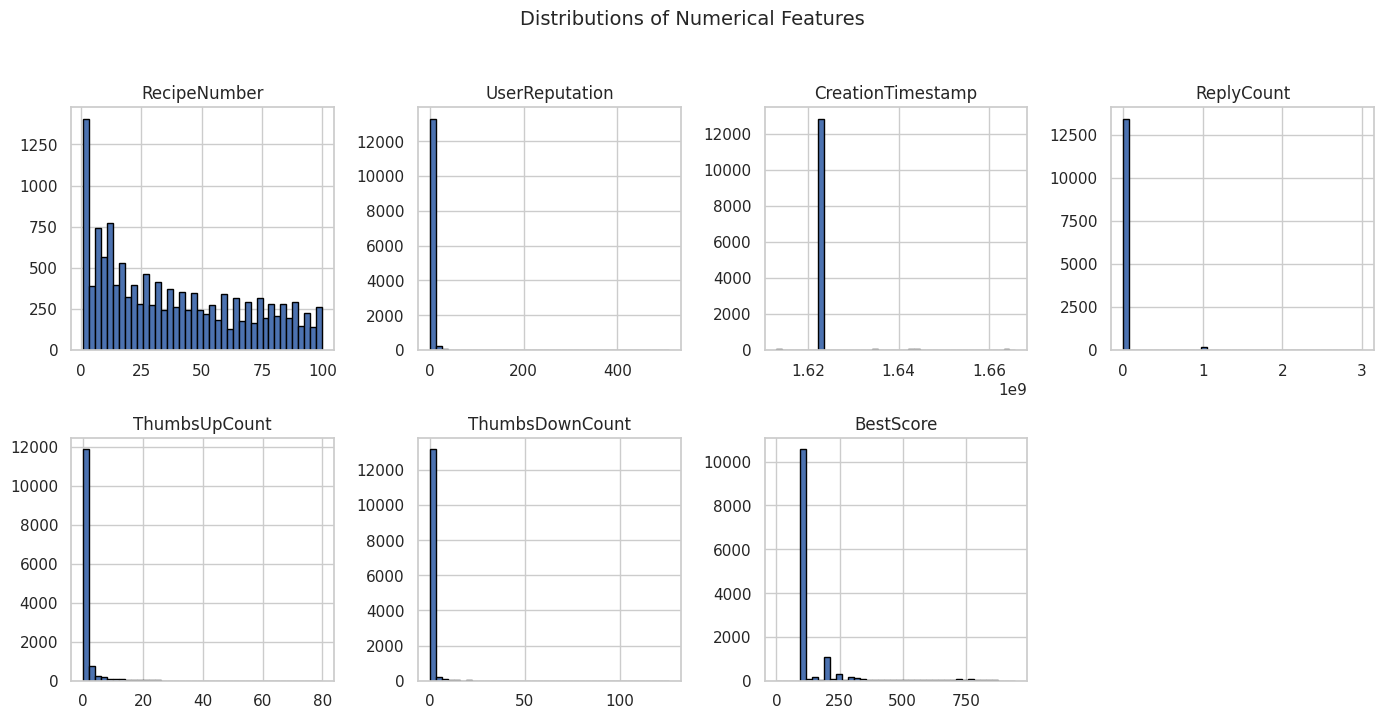

In [68]:
num_cols = ['RecipeNumber', 'UserReputation','CreationTimestamp', 'ReplyCount', 'ThumbsUpCount', 'ThumbsDownCount', 'BestScore']
train[num_cols].hist(bins=40, figsize=(14, 10), edgecolor="black", layout=(3, 4))
plt.suptitle("Distributions of Numerical Features", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

- **RecipeNumber** : No scaling problem,No extreme skew
- **UserReputation** : Highly skewed, need log transformation in pipeline
- **CreationTimestamp** : Raw timestamp not useful, Extract hour/day/month, Then drop this
- **ThumbsUpCount and ThumbsDownCount** : Log transform needed

# Target Variable (Rating) Analysis

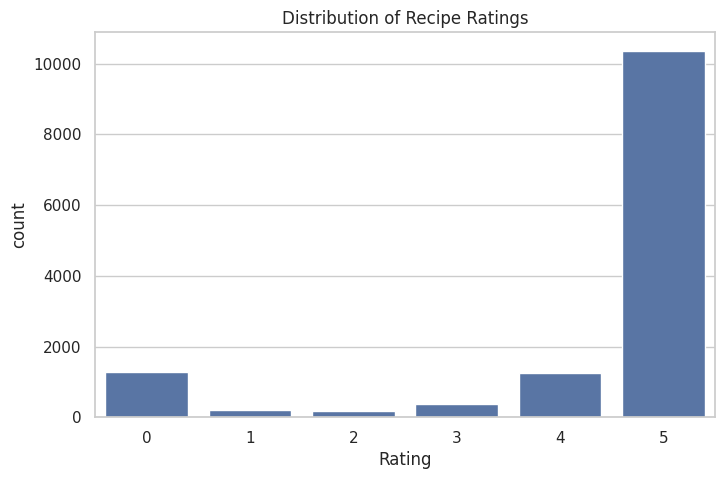

In [69]:
plt.figure(figsize=(8,5))
sns.countplot(data=train, x='Rating' )
plt.title("Distribution of Recipe Ratings")
plt.show()

This indicates a **class imbalance problem**, which may bias the model toward predicting rating 5 more frequently.
If `Rating = 0` means no rating, these rows should be removed before training.
- Rating = 5 dominates heavily
- Accuracy alone is misleading
- Rating = 0 Exists (A score on a 1 to 5 scale. A score of 0 means no score was given.)

# Missing Values Analysis

In [70]:
train.isna().sum()

ID                   0
RecipeNumber         0
RecipeCode           0
RecipeName           0
CommentID            0
UserID               0
UserName             0
UserReputation       0
CreationTimestamp    0
ReplyCount           0
ThumbsUpCount        0
ThumbsDownCount      0
Rating               0
BestScore            0
Recipe_Review        2
dtype: int64

there is 2 missing values in **Recipe_Review** but it not important,
- decide to replace with **"No Review"**

# Reputation vs Rating

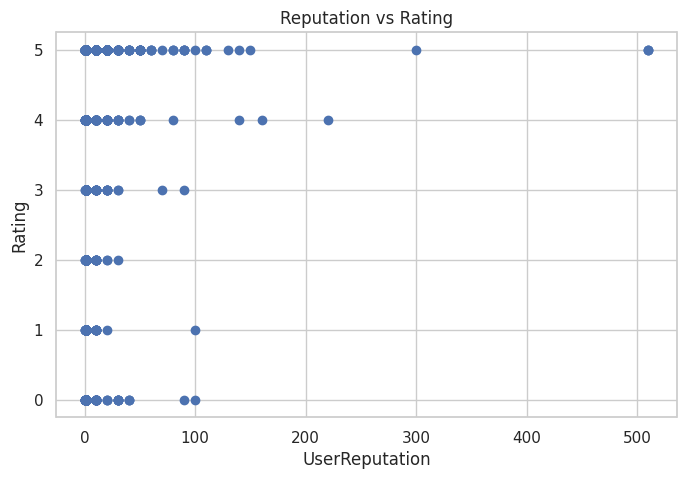

In [71]:
plt.figure(figsize=(8,5))
plt.scatter(train['UserReputation'],train['Rating'])
plt.title("Reputation vs Rating")
plt.xlabel("UserReputation")
plt.ylabel("Rating")
plt.show()

- Most users have very low reputation (0–50 range)
- High reputation users are rare
- 5-star ratings dominate across all reputation levels
- No strong linear pattern between reputation and rating

In [72]:
train['UserReputation'].value_counts()

UserReputation
1      12708
10       478
20       217
0        118
30        54
50        16
40        12
90         7
80         4
60         4
100        3
510        3
110        3
70         2
140        2
160        1
220        1
130        1
150        1
300        1
Name: count, dtype: int64

The distribution of UserReputation is highly skewed. The majority of users have a reputation score of 1, indicating that most reviews are submitted by low-reputation users. Only a small number of users have high reputation values .

Due to this strong right-skewness and presence of extreme values, a log transformation will be applied during preprocessing to stabilize variance and reduce the impact of outliers.

### Time-Based Features: Convert CreationTimestamp (Unix) into human-readable features.

In [73]:
train['CreationTimestamp'] = pd.to_datetime(
    train['CreationTimestamp'],
    unit = 's'
)
print(train['CreationTimestamp'].head())

train['hour'] = train['CreationTimestamp'].dt.hour
train['day_of_week'] = train['CreationTimestamp'].dt.dayofweek
train['month'] = train['CreationTimestamp'].dt.month

train = train.drop(columns=['CreationTimestamp'])
numeric_cols = [
    'RecipeNumber',
    'UserReputation',
    'ReplyCount',
    'ThumbsUpCount',
    'ThumbsDownCount',
    'BestScore',
    'hour',
    'month'
]

train[numeric_cols + ['Rating']].corr()



0   2021-06-03 10:44:38
1   2021-06-03 10:57:32
2   2021-06-03 10:49:17
3   2021-06-02 15:48:19
4   2021-06-03 11:04:20
Name: CreationTimestamp, dtype: datetime64[ns]


,RecipeNumber,UserReputation,ReplyCount,ThumbsUpCount,ThumbsDownCount,BestScore,hour,month,Rating
RecipeNumber,1.000000,0.022084,0.026537,0.064797,0.053027,0.086233,0.022926,0.007061,-0.043127
UserReputation,0.022084,1.000000,0.014045,0.053825,0.023986,0.126701,0.058706,0.030281,0.015038
ReplyCount,0.026537,0.014045,1.000000,0.220929,0.293614,0.210352,0.111571,0.045198,-0.124860
ThumbsUpCount,0.064797,0.053825,0.220929,1.000000,0.392564,0.693532,0.324584,0.145364,-0.051752
ThumbsDownCount,0.053027,0.023986,0.293614,0.392564,1.000000,0.227341,0.173244,0.098779,-0.142273
BestScore,0.086233,0.126701,0.210352,0.693532,0.227341,1.000000,0.444651,0.170093,-0.036719
hour,0.022926,0.058706,0.111571,0.324584,0.173244,0.444651,1.000000,0.008200,-0.036977
month,0.007061,0.030281,0.045198,0.145364,0.098779,0.170093,0.008200,1.000000,-0.025126
Rating,-0.043127,0.015038,-0.124860,-0.051752,-0.142273,-0.036719,-0.036977,-0.025126,1.000000


used to just for analys, any use with hour, day, month

# Correlation Heatmap

(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5]),
 [Text(0.5, 0, 'RecipeNumber'),
  Text(1.5, 0, 'UserReputation'),
  Text(2.5, 0, 'ReplyCount'),
  Text(3.5, 0, 'ThumbsUpCount'),
  Text(4.5, 0, 'ThumbsDownCount'),
  Text(5.5, 0, 'BestScore'),
  Text(6.5, 0, 'hour'),
  Text(7.5, 0, 'month'),
  Text(8.5, 0, 'Rating')])

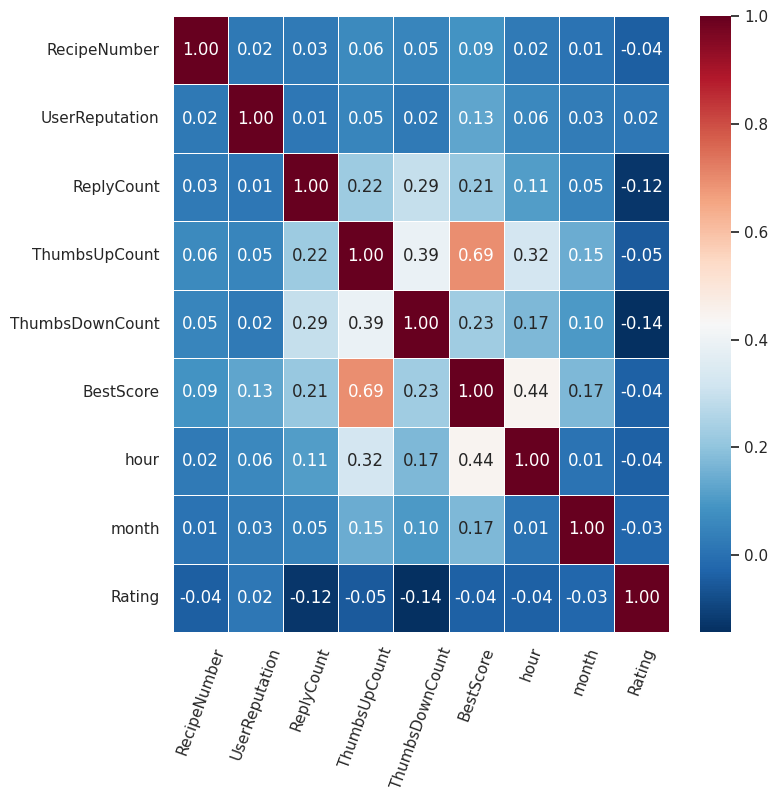

In [79]:
# imp_columns = ['RecipeNumber', 'UserReputation','ReplyCount','ThumbsUpCount', 'ThumbsDownCount', 'Rating', 'BestScore']
imp_columns = train[numeric_cols + ['Rating']].corr()
plt.figure(figsize = (8,8))
# sns.heatmap(train[imp_columns].corr(numeric_only = True), annot=True, cmap='RdBu_r',fmt=".2f",linewidths=0.5)
sns.heatmap(imp_columns, annot=True, cmap='RdBu_r',fmt=".2f",linewidths=0.5)
plt.xticks(rotation=70)


There is relation between **best score** and **ThumbsUpCount**

also between hour and ThumbsUpCount

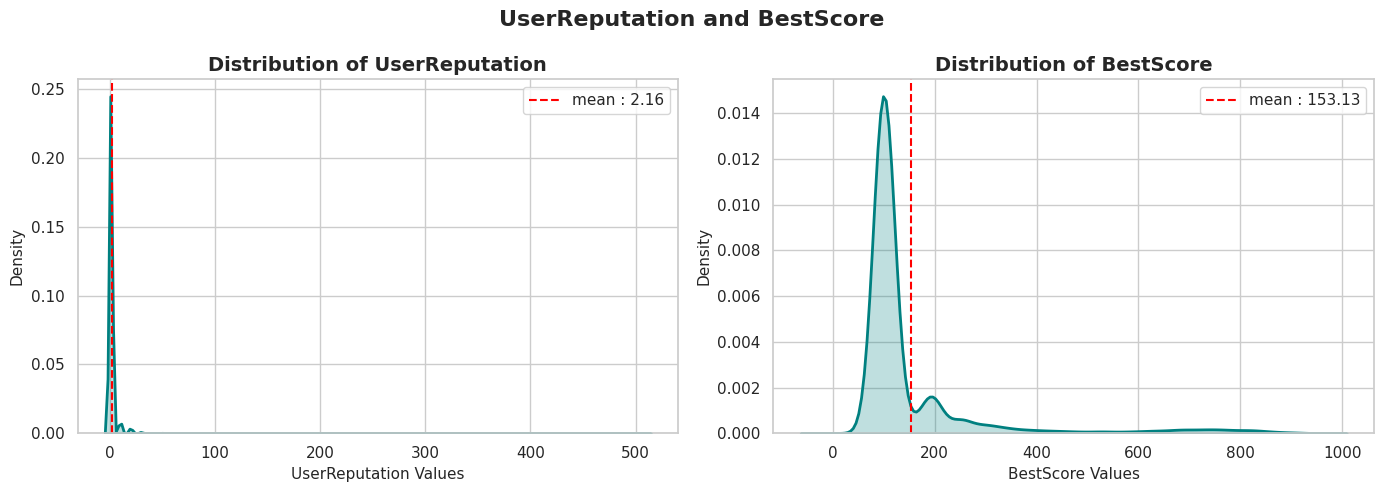

In [80]:
fig, ax = plt.subplots(1,2,figsize=(14, 5))

for i,col in  enumerate (['UserReputation','BestScore']):
    sns.kdeplot(data=train,x=col,fill = True,ax=ax[i],color = 'teal',linewidth=2)
    ax[i].set_title(f"Distribution of {col}",fontsize=14,fontweight='bold')
    ax[i].set_xlabel(f"{col} Values", fontsize=11)
    ax[i].set_ylabel("Density",fontsize=11)
    ax[i].axvline(train[col].mean(),color='red',linestyle='--',label=f'mean : {train[col].mean():.2f}')
    ax[i].legend()
plt.suptitle("UserReputation and BestScore", fontsize=16, fontweight='bold')
plt.tight_layout()


# Outlier Detection (Numerical Features)

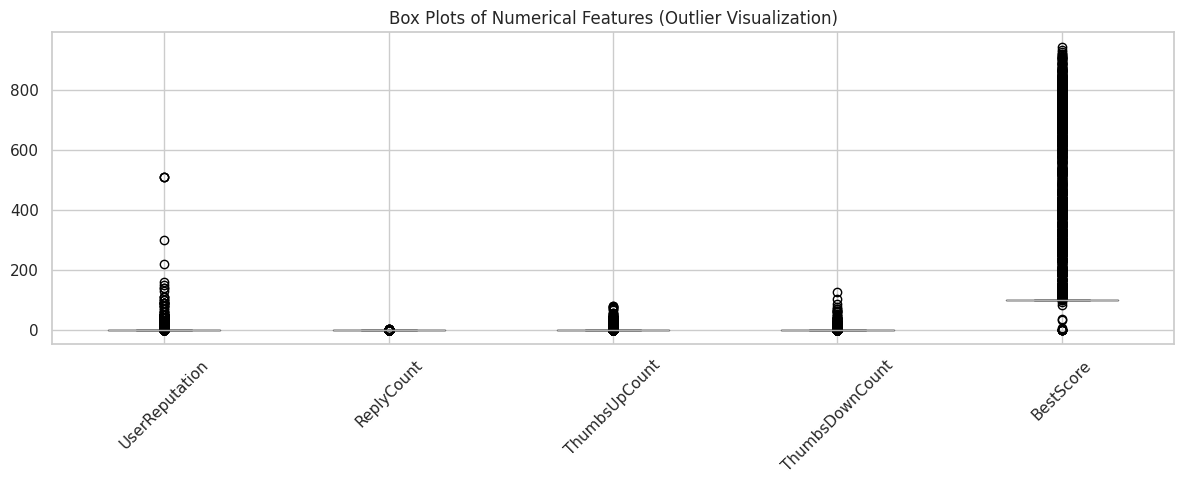

In [86]:
# Box plots for features that are not IDs (more interpretable)
plot_cols = ['UserReputation', 'ReplyCount', 'ThumbsUpCount', 'ThumbsDownCount', 'BestScore']
train[plot_cols].boxplot(figsize=(12, 5), rot=45)
plt.title("Box Plots of Numerical Features (Outlier Visualization)")
plt.tight_layout()
plt.show()

In [87]:
outlier_summary = {}

for col in plot_cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = train[(train[col] < lower_bound) | (train[col] > upper_bound)]
    
    outlier_summary[col] = {
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outliers.shape[0],
        "Outlier Percentage": round((outliers.shape[0] / len(train)) * 100, 2)
    }

pd.DataFrame(outlier_summary).T

,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
UserReputation,1.0,1.0,928.0,6.81
ReplyCount,0.0,0.0,172.0,1.26
ThumbsUpCount,0.0,0.0,3054.0,22.40
ThumbsDownCount,0.0,0.0,1820.0,13.35
BestScore,100.0,100.0,3130.0,22.95


Because features are highly right-skewed:

IQR will mark MANY values as outliers.These are NOT errors.They are natural heavy-tail distributions.

---
## 12. EDA Summary and Preprocessing Recommendations

Summary of Day 1 findings to guide **Day 2 preprocessing** and pipeline design.

### Summary of findings

| Area | Finding | Preprocessing implication |
|------|--------|----------------------------|
| **Missing values** | Recipe_Review has a small number of nulls (~2 rows) | Impute with empty string or drop rows; handle in pipeline |
| **Feature types** | Mix of numerical (10) and categorical (5 incl. text) | Use **ColumnTransformer**: scale numerics, encode categoricals |
| **Target** | Rating 0–5; imbalanced (many 5s) | Consider class weights or stratification in CV; regression (RMSE/R²) or classification (F1/ROC-AUC) |
| **Outliers** | ThumbsUp/ThumbsDown, ReplyCount, BestScore may have many IQR outliers | Consider capping inside pipeline |
| **Scaling** | Different scales (e.g. CreationTimestamp vs ReplyCount) | Apply **StandardScaler** (or MinMax) to numerical features in pipeline |
| **IDs** | ID, CommentID, UserID are identifiers | Exclude from features|
| **Time** | CreationTimestamp is Unix time | Option: use as-is or derive year/month; ensure same transform on test |
| **Text** | Recipe_Review optional |  drop  |

### Next steps (Day 2)

1. Define final feature lists (numeric vs categorical) and drop ID-like columns.
2. Build **sklearn Pipeline** with **ColumnTransformer** (numeric + categorical).
3. Handle missing values inside the pipeline (e.g. SimpleImputer for numeric; constant for text).
4. Integrate scaling and encoding; then add baseline and 4+ models with cross-validation.

### Summary of findings

- **Dataset readiness**: Train has **13,636 rows** and includes both **numerical** and **categorical/text** features; test has **4,546 rows**.
- **Missing values**: `Recipe_Review` has a **very small number of nulls** (can be imputed as empty text).
- **Target distribution**: `Rating` is **imbalanced** (many 5-star ratings), so model evaluation should consider imbalance handling.
- **Outliers / skewness**: Engagement features (`ThumbsUpCount`, `ThumbsDownCount`, `ReplyCount`, `BestScore`) are **right-skewed**; many IQR “outliers” are **natural heavy-tail values**, not necessarily errors.
- **Pipeline implications**:
  - Use `ColumnTransformer` to apply **imputation + scaling** for numeric and **encoding** for categorical.
  - Treat ID-like columns (`ID`, `CommentID`, `UserID`) carefully to avoid leakage (often dropped from modeling features).

**Next step**: Implement preprocessing **inside an sklearn Pipeline** (no manual preprocessing outside), then build baseline + multiple models with cross-validation.